In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('/kaggle/input/datasets/alexteboul/diabetes-health-indicators-dataset/diabetes_binary_health_indicators_BRFSS2015.csv')

# Quick cleaning from Phase 2
df = df.drop_duplicates()
df = df[df['BMI'] <= 60]
df = df.drop(columns=['CholCheck'])

X = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary']

print("Shape:", df.shape)

Shape: (228669, 21)


## 1. Train-Test Split

In [2]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("\nClass distribution in training set:")
print(y_train.value_counts(normalize=True).round(4) * 100)


Training set: (182935, 20)
Testing set: (45734, 20)

Class distribution in training set:
Diabetes_binary
0.0    84.73
1.0    15.27
Name: proportion, dtype: float64



Data split into 80% training and 20% testing. 
Stratify=y ensures both sets have the same class 
distribution as the original dataset, which is 
important given our class imbalance.

## 2. Feature Scaling

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done!")






Scaling done!


StandardScaler applied to training data using fit_transform, 
and only transform on test data. This is important — 
we never fit the scaler on test data to avoid data leakage.

## 3. Model Training

=== Logistic Regression ===
Accuracy: 0.7171

Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.71      0.81     38749
         1.0       0.32      0.75      0.45      6985

    accuracy                           0.72     45734
   macro avg       0.63      0.73      0.63     45734
weighted avg       0.85      0.72      0.75     45734



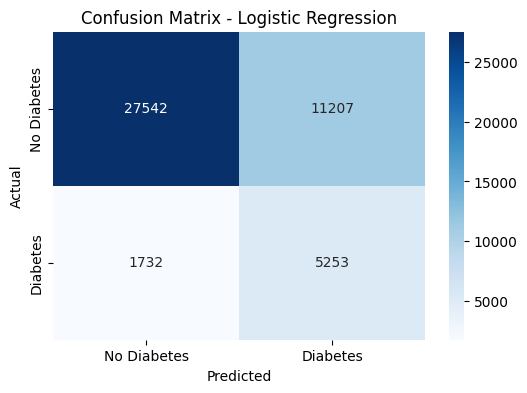

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

lr = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

print("=== Logistic Regression ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_lr), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

# Confusion Matrix
plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), 
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()



Logistic Regression trained with class_weight='balanced' 
to handle class imbalance. This tells the model to pay 
more attention to the minority class (diabetic patients) 
during training.

=== Decision Tree ===
Accuracy: 0.6945

Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.68      0.79     38749
         1.0       0.30      0.77      0.43      6985

    accuracy                           0.69     45734
   macro avg       0.62      0.72      0.61     45734
weighted avg       0.84      0.69      0.74     45734



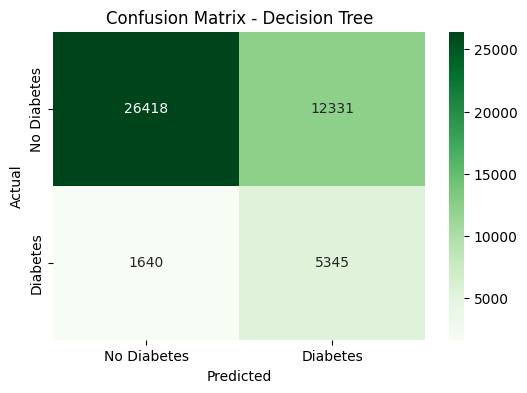

In [5]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42, class_weight='balanced', max_depth=10)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

print("=== Decision Tree ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_dt), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_dt),
            annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - Decision Tree')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()



Decision Tree trained with max_depth=10 to prevent 
overfitting. class_weight='balanced' applied to 
handle class imbalance same as Logistic Regression.

=== Random Forest ===
Accuracy: 0.8454

Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.97      0.91     38749
         1.0       0.48      0.15      0.23      6985

    accuracy                           0.85     45734
   macro avg       0.67      0.56      0.57     45734
weighted avg       0.81      0.85      0.81     45734



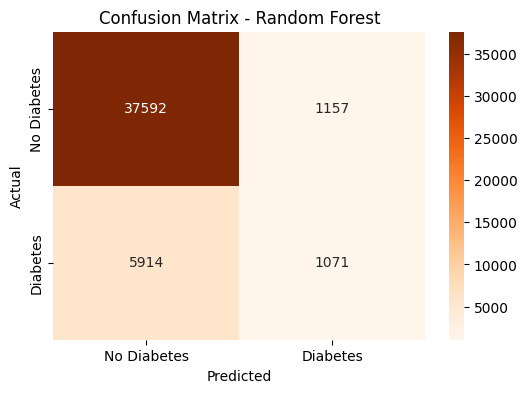

In [6]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, 
                            class_weight='balanced', n_jobs=-1)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print("=== Random Forest ===")
print("Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

plt.figure(figsize=(6,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()



Random Forest builds 100 decision trees and combines 
their predictions. It is more powerful than a single 
Decision Tree because it reduces overfitting by 
averaging results across many trees.

              Model  Accuracy  Diabetes Precision  Diabetes Recall  Diabetes F1
Logistic Regression    0.7171                0.32             0.75         0.45
      Decision Tree    0.6945                0.30             0.77         0.43
      Random Forest    0.8454                0.48             0.15         0.23


/tmp/ipykernel_17/1608590383.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(results_df['Model'], rotation=15)
/tmp/ipykernel_17/1608590383.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(results_df['Model'], rotation=15)


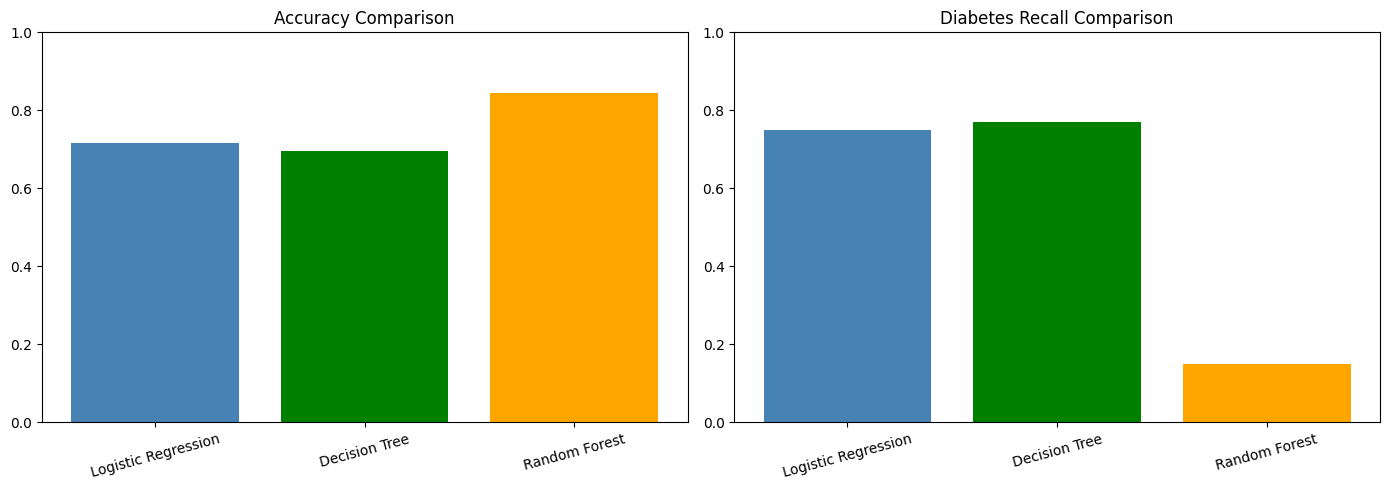

In [7]:
# Model comparison
results = {
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [0.7171, 0.6945, 0.8454],
    'Diabetes Precision': [0.32, 0.30, 0.48],
    'Diabetes Recall': [0.75, 0.77, 0.15],
    'Diabetes F1': [0.45, 0.43, 0.23]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Accuracy comparison
axes[0].bar(results_df['Model'], results_df['Accuracy'], color=['steelblue','green','orange'])
axes[0].set_title('Accuracy Comparison')
axes[0].set_ylim(0, 1)
axes[0].set_xticklabels(results_df['Model'], rotation=15)

# Recall comparison
axes[1].bar(results_df['Model'], results_df['Diabetes Recall'], color=['steelblue','green','orange'])
axes[1].set_title('Diabetes Recall Comparison')
axes[1].set_ylim(0, 1)
axes[1].set_xticklabels(results_df['Model'], rotation=15)

plt.tight_layout()
plt.show()



Comparison shows a tradeoff between accuracy and recall. 
Logistic Regression and Decision Tree sacrifice overall 
accuracy but detect more diabetic patients (higher recall). 
Random Forest has highest accuracy but misses most 
diabetic patients — less suitable for medical diagnosis.
For diabetes detection, high recall is more important 
than high accuracy since missing a diabetic patient 
is more dangerous than a false alarm.

In [8]:
df_final = X.copy()
df_final['Diabetes_binary'] = y.values
df_final.to_csv('/kaggle/working/diabetes_final_results.csv', index=False)
print("Saved successfully!")



Saved successfully!


## 4. Conclusion

This project trained three ML models on the CDC Diabetes 
Health Indicators Dataset to predict diabetes risk.

**Key Findings:**
- Logistic Regression achieved best diabetes recall (0.75) 
  making it most suitable for medical diagnosis
- Random Forest achieved highest accuracy (0.85) but 
  poor diabetes recall (0.15) due to class imbalance
- Decision Tree balanced both with recall of 0.77

**Most Important Features (from Phase 3):**
- HighBP, BMI, GenHlth, Age and PhysHlth were 
  consistently the strongest predictors across 
  all 5 importance methods

**Research Questions Answered:**
- Q1: Yes, ML models can predict diabetes risk — 
  Logistic Regression achieves 75% recall
- Q2: HighBP, BMI and GenHlth are the most 
  significant predictors of diabetes risk